# Book Review Sentiment Classification using RNN, LSTM, and Pre-trained Embeddings

**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio – Part III Language Task  
**Student:** Adarsha Ghimire

**Dataset:** Book Review Dataset  
**Task:** Sentiment classification from book review text

## Project Aim

This notebook builds an end-to-end Natural Language Processing pipeline for **book review sentiment classification**.

The original dataset contains ratings from **1 to 5**. To align the task more clearly with the coursework requirement of **sentiment analysis/text classification**, the ratings are converted into three sentiment classes:

| Rating | Sentiment Class |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |


The notebook includes:

1. Dataset loading from ZIP  
2. Dataset understanding and class distribution  
3. Text preprocessing  
4. Tokenization and sequence padding  
5. Train/validation/test split  
6. Model 1: Simple RNN with trainable Embedding  
7. Model 2: LSTM with trainable Embedding  
8. Model 3: LSTM with pre-trained GloVe/Word2Vec-style embeddings  
9. Model evaluation using accuracy, confusion matrix, classification report, precision, recall, and F1-score  
10. Error analysis using misclassified reviews  
11. Real-time prediction interface using a prediction function and optional Gradio GUI  



## 1. Import Required Libraries

In [5]:
import os
import re
import glob
import time
import zipfile
import shutil
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: []


## 2. Mount Google Drive and Extract Dataset ZIP

The notebook searches Google Drive for a ZIP file containing **Book Review Dataset**.



If the file has a slightly different name, the search logic should still find it as long as the ZIP filename contains `Book`, `Review`, and `Dataset`.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob

# Dataset folder
DATASET_DIR = "/content/drive/MyDrive/Book_Review_Dataset"

# Check folder exists
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError("Dataset folder not found.")

print("Dataset folder found:", DATASET_DIR)

# Find CSV files
csv_candidates = glob.glob(DATASET_DIR + "/**/*.csv", recursive=True)

print("\nCSV candidates found:")
for c in csv_candidates:
    print(c)

if len(csv_candidates) == 0:
    raise FileNotFoundError("No CSV file found in dataset folder.")

# Prefer Book_review.csv if available
preferred = [
    c for c in csv_candidates
    if os.path.basename(c).lower() == "book_review.csv"
]

CSV_PATH = preferred[0] if preferred else csv_candidates[0]

print("\nSelected CSV:", CSV_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder found: /content/drive/MyDrive/Book_Review_Dataset

CSV candidates found:
/content/drive/MyDrive/Book_Review_Dataset/Book_review.csv

Selected CSV: /content/drive/MyDrive/Book_Review_Dataset/Book_review.csv


## 3. Load and Understand the Dataset

In [7]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# Keep only required columns
required_columns = ["rating", "reviewText", "summary"]
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required_columns].copy()

# Handle missing text
df["reviewText"] = df["reviewText"].fillna("")
df["summary"] = df["summary"].fillna("")

# Combine review text and summary for richer input
df["combined_text"] = df["summary"].astype(str) + " " + df["reviewText"].astype(str)

# Make sure rating is numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"])
df["rating"] = df["rating"].astype(int)

# Keep only valid ratings 1 to 5
df = df[df["rating"].between(1, 5)].copy()

print("Cleaned dataset shape:", df.shape)
display(df.head())


Dataset shape: (12000, 4)

Columns:
['Unnamed: 0', 'rating', 'reviewText', 'summary']


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


Cleaned dataset shape: (12000, 4)


,rating,reviewText,summary,combined_text
0,5,This book was the very first bookmobile book I...,50 + years ago...,50 + years ago... This book was the very first...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!,Boring! Boring! Boring! When I read the descri...
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!,Wiggleliscious/new toy ready/!! I just had to ...
3,5,I don't normally buy 'mystery' novels because ...,Very good read.,Very good read. I don't normally buy 'mystery'...
4,5,"This isn't the kind of book I normally read, a...",Great Story!,Great Story! This isn't the kind of book I nor...


## 4. Convert Ratings into Sentiment Classes

The original dataset uses ratings from 1 to 5.  
For sentiment analysis, these ratings are grouped into three classes:

- **Negative:** ratings 1 and 2  
- **Neutral:** rating 3  
- **Positive:** ratings 4 and 5  

This makes the task more suitable for sentiment classification and improves interpretability.


In [8]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

def rating_to_label(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df["label"] = df["rating"].apply(rating_to_label)

label_mapping = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Rating to sentiment conversion complete.")
display(df[["rating", "sentiment", "summary", "reviewText"]].head())


Rating to sentiment conversion complete.


,rating,sentiment,summary,reviewText
0,5,Positive,50 + years ago...,This book was the very first bookmobile book I...
1,1,Negative,Boring! Boring! Boring!,"When I read the description for this book, I c..."
2,5,Positive,Wiggleliscious/new toy ready/!!,I just had to edit this review. This book is a...
3,5,Positive,Very good read.,I don't normally buy 'mystery' novels because ...
4,5,Positive,Great Story!,"This isn't the kind of book I normally read, a..."


## 5. Exploratory Data Analysis

Original rating distribution:


,count
rating,
1,2000
2,2000
3,2000
4,3000
5,3000


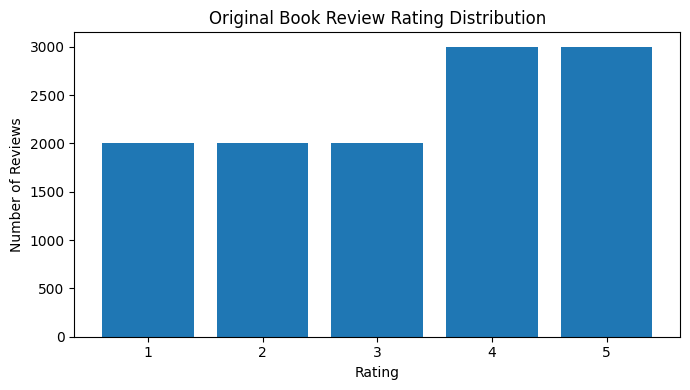

Sentiment class distribution:


,count
sentiment,
Positive,6000
Negative,4000
Neutral,2000


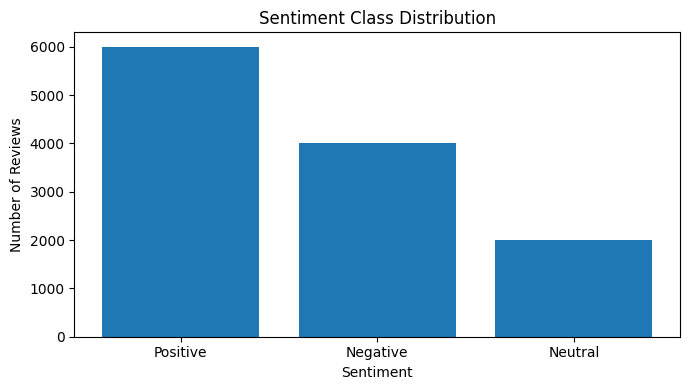

Text length statistics:


,text_length_words
count,12000.00000
mean,113.21750
std,126.80282
min,3.00000
25%,35.00000
50%,65.00000
75%,139.00000
max,2161.00000


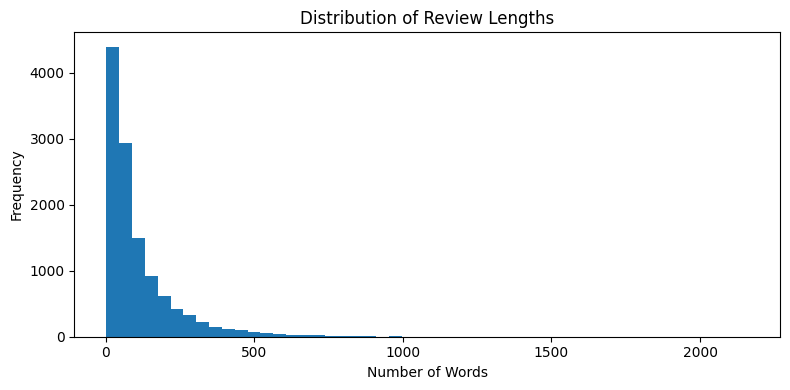

In [9]:
print("Original rating distribution:")
rating_counts = df["rating"].value_counts().sort_index()
display(rating_counts)

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Original Book Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

print("Sentiment class distribution:")
sentiment_counts = df["sentiment"].value_counts()
display(sentiment_counts)

plt.figure(figsize=(7, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

df["text_length_words"] = df["combined_text"].apply(lambda x: len(str(x).split()))

print("Text length statistics:")
display(df["text_length_words"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["text_length_words"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 6. Text Preprocessing

The coursework requires preprocessing such as:

- lowercase conversion  
- removing URLs  
- removing mentions and hashtags  
- removing numbers and special characters  
- handling contractions  
- stopword removal  
- lemmatization  

This cell performs these steps.


In [10]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Keep negation words because they are important for sentiment.
for neg_word in ["no", "not", "nor"]:
    if neg_word in stop_words:
        stop_words.remove(neg_word)

# Small contraction dictionary to avoid depending on extra packages
contractions_dict = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "what's": "what is", "you're": "you are", "you've": "you have",
    "we're": "we are", "they're": "they are", "he's": "he is", "she's": "she is"
}

def expand_contractions(text):
    text = str(text)
    for contraction, expanded in contractions_dict.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", expanded, text)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters, keep alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

start_time = time.time()
df["cleaned_text"] = df["combined_text"].apply(clean_text)
print(f"Text cleaning completed in {time.time() - start_time:.2f} seconds.")

display(df[["rating", "sentiment", "combined_text", "cleaned_text"]].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Text cleaning completed in 18.93 seconds.


,rating,sentiment,combined_text,cleaned_text
0,5,Positive,50 + years ago... This book was the very first...,year ago book first bookmobile book bought sch...
1,1,Negative,Boring! Boring! Boring! When I read the descri...,boring boring boring read description book cou...
2,5,Positive,Wiggleliscious/new toy ready/!! I just had to ...,wiggleliscious new toy ready edit review book ...
3,5,Positive,Very good read. I don't normally buy 'mystery'...,good read not normally buy mystery novel not l...
4,5,Positive,Great Story! This isn't the kind of book I nor...,great story not kind book normally read althou...


## 7. Visualize Cleaned Text

,word,count
0,not,19438
1,book,16616
2,story,12355
3,read,9246
4,one,6392
5,character,5943
6,like,5424
7,good,5423
8,would,5000
9,love,4230


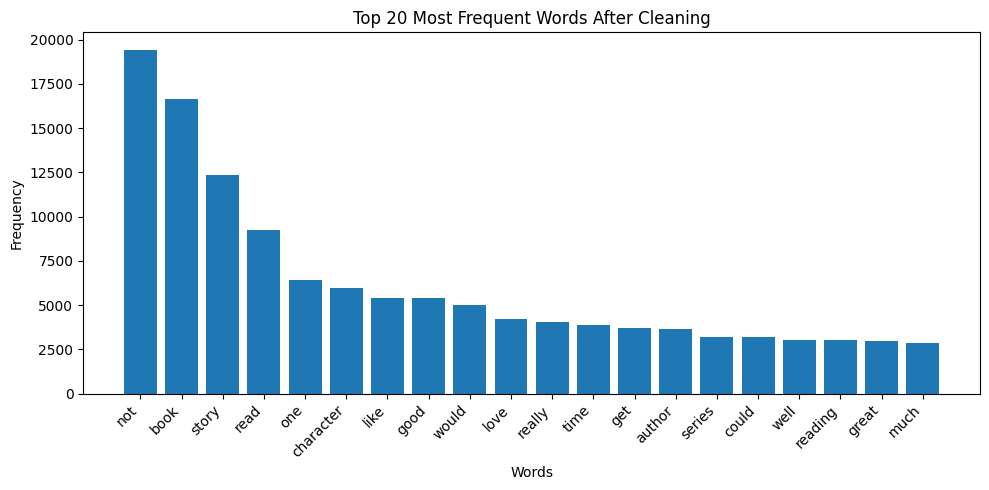

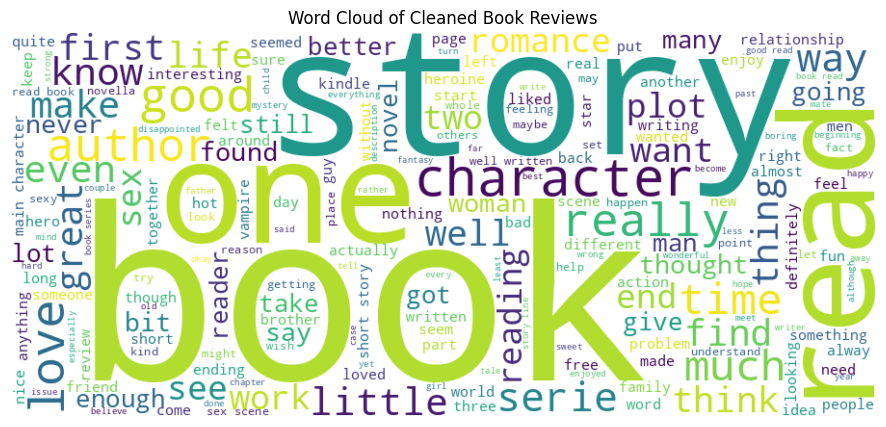

In [11]:
all_words = " ".join(df["cleaned_text"]).split()
word_counts = Counter(all_words)
most_common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

display(most_common_words)

plt.figure(figsize=(10, 5))
plt.bar(most_common_words["word"], most_common_words["count"])
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional word cloud
try:
    from wordcloud import WordCloud

    text_for_cloud = " ".join(df["cleaned_text"].sample(min(3000, len(df)), random_state=SEED))
    wc = WordCloud(width=900, height=400, background_color="white").generate(text_for_cloud)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Cleaned Book Reviews")
    plt.show()
except Exception as e:
    print("WordCloud could not be generated:", e)


## 8. Prepare Train/Validation/Test Split

The coursework asks to divide the dataset into training, validation, and test sets.

We use:

- 70% training  
- 15% validation  
- 15% testing  

The split is stratified so sentiment distribution is preserved across sets.


In [12]:
# Remove empty cleaned texts
df_model = df[df["cleaned_text"].str.len() > 0].copy()

X = df_model["cleaned_text"].values
y = df_model["label"].values

# First split: train 70%, temp 30%
X_train, X_temp, y_train, y_temp, train_idx, temp_idx = train_test_split(
    X,
    y,
    df_model.index.values,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: validation 15%, test 15%
X_val, X_test, y_val, y_test, val_idx, test_idx = train_test_split(
    X_temp,
    y_temp,
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(y_train).map(label_mapping).value_counts())

print("\nValidation label distribution:")
print(pd.Series(y_val).map(label_mapping).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).map(label_mapping).value_counts())

# Class weights help with imbalance, especially if Positive reviews dominate.
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_train), class_weights_values)
}

print("\nClass weights:")
print(class_weights)


Training samples: 8400
Validation samples: 1800
Test samples: 1800

Training label distribution:
Positive    4200
Negative    2800
Neutral     1400
Name: count, dtype: int64

Validation label distribution:
Positive    900
Negative    600
Neutral     300
Name: count, dtype: int64

Test label distribution:
Positive    900
Negative    600
Neutral     300
Name: count, dtype: int64

Class weights:
{0: 1.0, 1: 2.0, 2: 0.6666666666666666}


## 9. Tokenization and Percentile-Based Padding

The coursework requires Keras Tokenizer and sequence padding.

We use percentile-based padding to avoid very long reviews making the model unnecessarily slow.


In [13]:
MAX_NUM_WORDS = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

train_lengths = [len(seq) for seq in X_train_seq]

# Percentile-based sequence length, capped for efficiency
percentile_len = int(np.percentile(train_lengths, 90))
MAX_SEQUENCE_LENGTH = min(max(percentile_len, 50), 200)

print("90th percentile sequence length:", percentile_len)
print("Final MAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)
num_classes = 3

print("Vocabulary size:", vocab_size)
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)


90th percentile sequence length: 135
Final MAX_SEQUENCE_LENGTH: 135
Vocabulary size: 20000
X_train_pad shape: (8400, 135)
X_val_pad shape: (1800, 135)
X_test_pad shape: (1800, 135)


## 10. Helper Functions for Training and Evaluation

In [14]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    plt.xlabel("Predicted Sentiment")
    plt.ylabel("True Sentiment")
    plt.tight_layout()
    plt.show()

def evaluate_text_model(model, X_data, y_true, model_name):
    y_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 60)
    print(f"{model_name} Test Evaluation")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    sentiment_labels = ["Negative", "Neutral", "Positive"]

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=sentiment_labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, sentiment_labels, f"{model_name} - Confusion Matrix")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }, y_pred, y_prob

EPOCHS = 8
BATCH_SIZE = 64
EMBEDDING_DIM = 100


# Model 1: Simple RNN with Trainable Embedding

In [15]:
def build_simple_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
print("Training Simple RNN model...")
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

rnn_time = time.time() - start_time
print(f"Simple RNN training time: {rnn_time:.2f} seconds")


Training Simple RNN model...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.3370 - loss: 1.1069 - val_accuracy: 0.2067 - val_loss: 1.1035 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.3569 - loss: 1.0923 - val_accuracy: 0.3917 - val_loss: 1.1095 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.3712 - loss: 1.0955 - val_accuracy: 0.3550 - val_loss: 1.0980 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.3931 - loss: 1.0571 - val_accuracy: 0.3656 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 5/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.4288 - loss: 1.0158 - val_accuracy: 0.3594 - val_loss: 1.1059 - learning_rate: 0.0010
Epoch 6/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.4065 - loss: 0.9917 - val_accuracy: 0.3589 - val_loss: 1.1321 - learning_rate: 0.0010
Epoch 7/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step

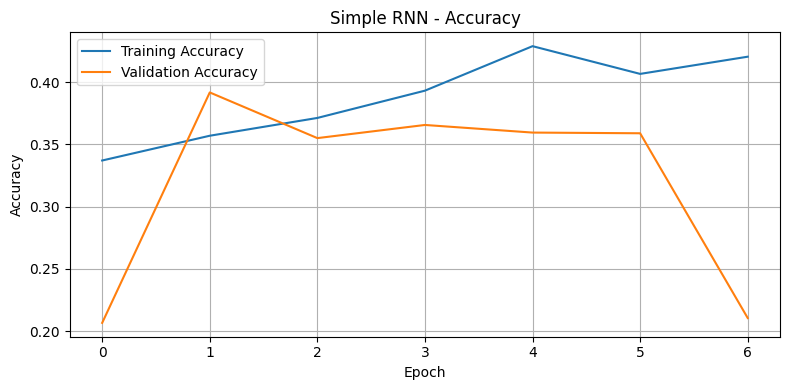

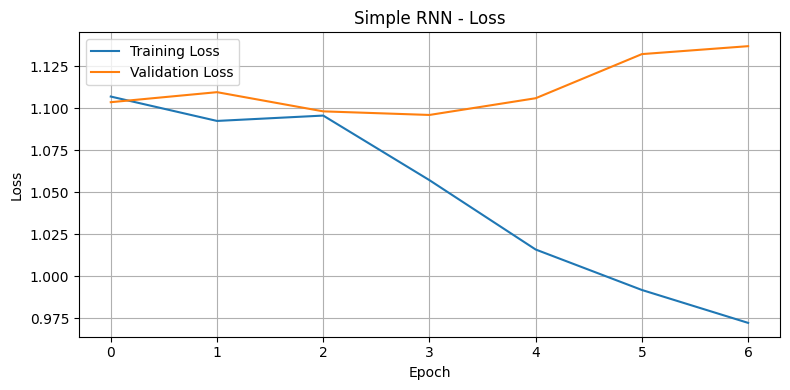


Simple RNN Test Evaluation
Accuracy : 0.3456
Precision: 0.3788
Recall   : 0.3456
F1-score : 0.2511

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.88      0.49       600
     Neutral       0.14      0.04      0.06       300
    Positive       0.48      0.09      0.15       900

    accuracy                           0.35      1800
   macro avg       0.32      0.34      0.24      1800
weighted avg       0.38      0.35      0.25      1800



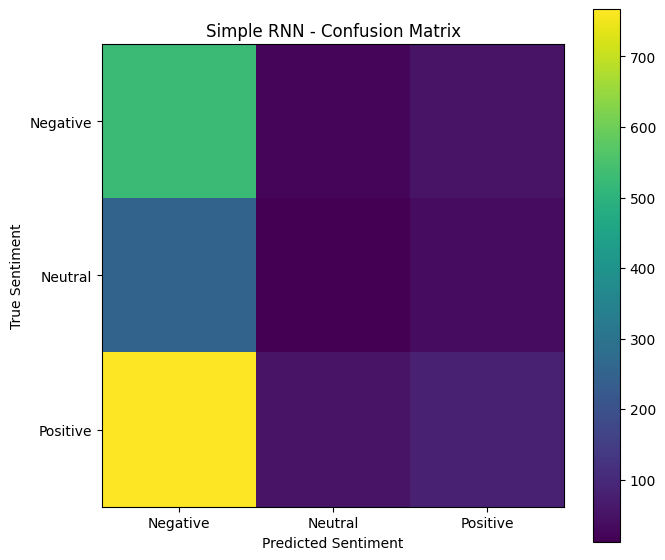

In [17]:
plot_history(history_rnn, "Simple RNN")
rnn_results, rnn_pred, rnn_prob = evaluate_text_model(rnn_model, X_test_pad, y_test, "Simple RNN")


# Model 2: LSTM with Trainable Embedding

In [18]:
def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        LSTM(96, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("Training LSTM model...")
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")


Training LSTM model...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 43s 302ms/step - accuracy: 0.3056 - loss: 1.0996 - val_accuracy: 0.3344 - val_loss: 1.0978 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 286ms/step - accuracy: 0.3486 - loss: 1.0960 - val_accuracy: 0.4778 - val_loss: 1.0872 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 296ms/step - accuracy: 0.4118 - loss: 1.0772 - val_accuracy: 0.4978 - val_loss: 1.0802 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.3780 - loss: 1.0419 - val_accuracy: 0.3644 - val_loss: 1.0785 - learning_rate: 0.0010
Epoch 5/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.3796 - loss: 1.0145 - val_accuracy: 0.2033 - val_loss: 1.1131 - learning_rate: 0.0010
Epoch 6/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 283ms/step - accuracy: 0.3804 - loss: 1.0010 - val_accuracy: 0.2017 - val_loss: 1.1406 - learning_rate: 0.0010
Epoch 7/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step

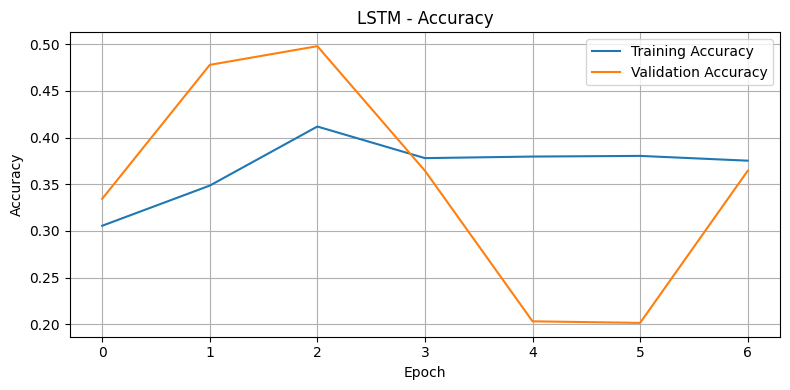

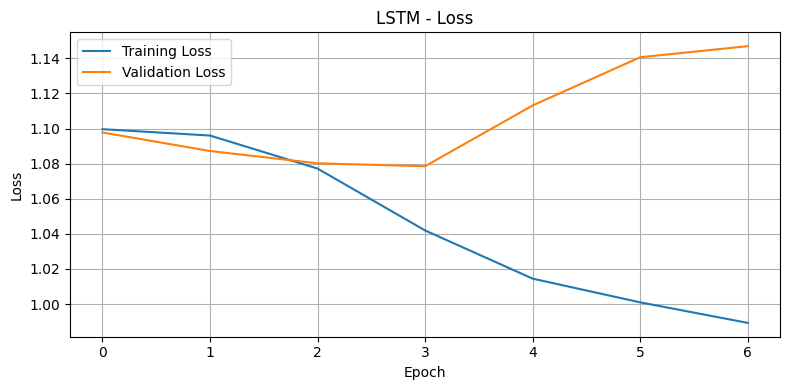


LSTM Test Evaluation
Accuracy : 0.3511
Precision: 0.4354
Recall   : 0.3511
F1-score : 0.2430

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.92      0.49       600
     Neutral       0.24      0.04      0.06       300
    Positive       0.57      0.08      0.14       900

    accuracy                           0.35      1800
   macro avg       0.38      0.34      0.23      1800
weighted avg       0.44      0.35      0.24      1800



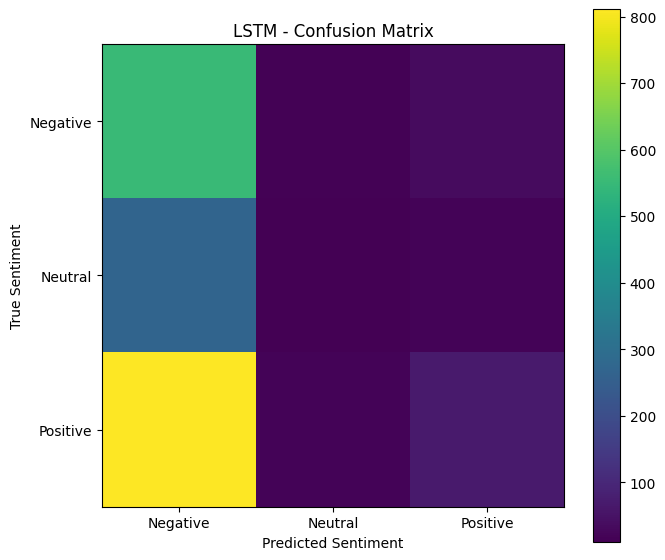

In [20]:
plot_history(history_lstm, "LSTM")
lstm_results, lstm_pred, lstm_prob = evaluate_text_model(lstm_model, X_test_pad, y_test, "LSTM")


# Model 3: LSTM with Pre-trained GloVe/Word2Vec-style Embeddings

The coursework asks for an LSTM model using pre-trained Word2Vec embeddings.

This notebook uses `gensim.downloader` to load a small pre-trained embedding model: `glove-twitter-100`.

GloVe is not exactly Word2Vec, but it is a widely used pre-trained word embedding model and is acceptable for demonstrating pre-trained embeddings. If download fails due to internet or package issues, the notebook falls back safely and explains the issue.


In [21]:
# Install gensim quietly if needed
try:
    import gensim.downloader as api
    print("gensim is already available.")
except Exception:
    print("Installing gensim...")
    !pip -q install gensim
    import gensim.downloader as api

PRETRAINED_AVAILABLE = False
embedding_model = None
PRETRAINED_DIM = 100

try:
    print("Loading pre-trained embeddings: glove-twitter-100")
    embedding_model = api.load("glove-twitter-100")
    PRETRAINED_AVAILABLE = True
    print("Pre-trained embeddings loaded successfully.")
except Exception as e:
    print("Could not load glove-twitter-100.")
    print("Reason:", e)

    try:
        print("Trying smaller fallback model: glove-twitter-25")
        embedding_model = api.load("glove-twitter-25")
        PRETRAINED_AVAILABLE = True
        PRETRAINED_DIM = 25
        print("Fallback pre-trained embeddings loaded successfully.")
    except Exception as e2:
        print("Could not load fallback pre-trained embeddings.")
        print("Reason:", e2)
        print("The notebook will continue using a randomly initialized embedding matrix.")
        PRETRAINED_AVAILABLE = False

embedding_matrix = np.zeros((vocab_size, PRETRAINED_DIM))

if PRETRAINED_AVAILABLE:
    found_words = 0

    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue

        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found_words += 1

    print("Words found in pre-trained embedding model:", found_words)
    print("Embedding coverage:", round(found_words / vocab_size * 100, 2), "%")
else:
    # Safe fallback, keeps notebook runnable
    np.random.seed(SEED)
    embedding_matrix = np.random.normal(0, 0.05, size=(vocab_size, PRETRAINED_DIM))
    embedding_matrix[0] = np.zeros(PRETRAINED_DIM)

print("Embedding matrix shape:", embedding_matrix.shape)


Installing gensim...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.4 MB/s eta 0:00:00
Loading pre-trained embeddings: glove-twitter-100
[==================================================] 100.0% 387.1/387.1MB downloaded
Pre-trained embeddings loaded successfully.
Words found in pre-trained embedding model: 17525
Embedding coverage: 87.62 %
Embedding matrix shape: (20000, 100)


In [22]:
def build_pretrained_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_SEQUENCE_LENGTH,
            trainable=False
        ),
        LSTM(96, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

pretrained_lstm_model = build_pretrained_lstm_model()
pretrained_lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [23]:
print("Training LSTM with pre-trained embeddings...")
start_time = time.time()

history_pretrained_lstm = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

pretrained_lstm_time = time.time() - start_time
print(f"Pre-trained embedding LSTM training time: {pretrained_lstm_time:.2f} seconds")


Training LSTM with pre-trained embeddings...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 417ms/step - accuracy: 0.3377 - loss: 1.1001 - val_accuracy: 0.4806 - val_loss: 1.0925 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 58s 240ms/step - accuracy: 0.3663 - loss: 1.0992 - val_accuracy: 0.3539 - val_loss: 1.0829 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.3298 - loss: 1.1001 - val_accuracy: 0.3411 - val_loss: 1.0955 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 42s 241ms/step - accuracy: 0.3463 - loss: 1.0975 - val_accuracy: 0.4889 - val_loss: 1.0821 - learning_rate: 0.0010
Epoch 5/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.3623 - loss: 1.0873 - val_accuracy: 0.6528 - val_loss: 0.9872 - learning_rate: 0.0010
Epoch 6/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 33s 251ms/step - accuracy: 0.3629 - loss: 1.0951 - val_accuracy: 0.3267 - val_loss: 1.1078 - learning_rate: 0.0010
Epoch 7/8
132/132 ━━━━━━━━━━━━━

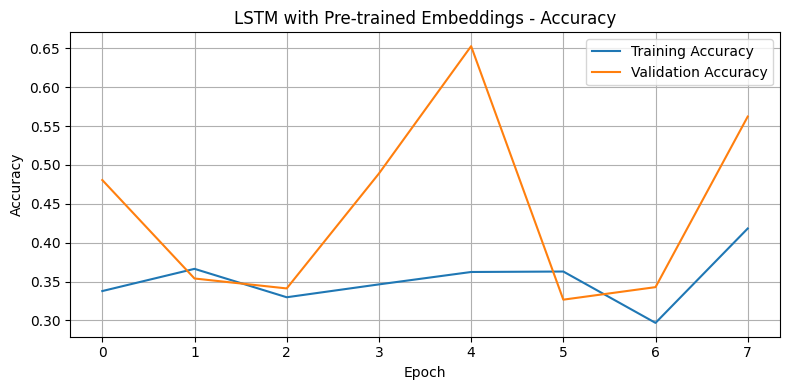

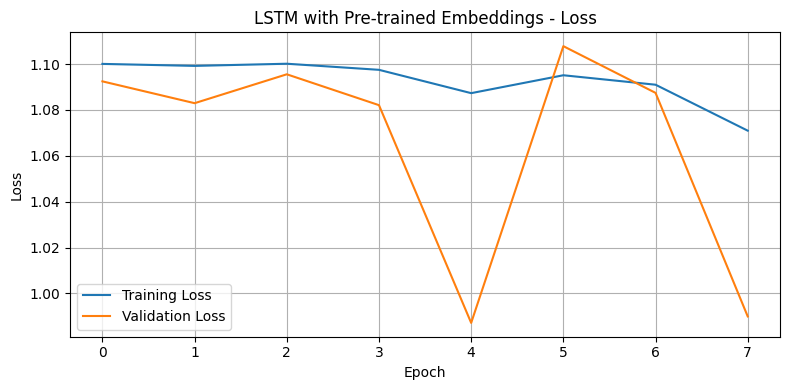


LSTM with Pre-trained Embeddings Test Evaluation
Accuracy : 0.6456
Precision: 0.6108
Recall   : 0.6456
F1-score : 0.5921

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.84      0.67       600
     Neutral       0.33      0.01      0.01       300
    Positive       0.74      0.73      0.73       900

    accuracy                           0.65      1800
   macro avg       0.54      0.53      0.47      1800
weighted avg       0.61      0.65      0.59      1800



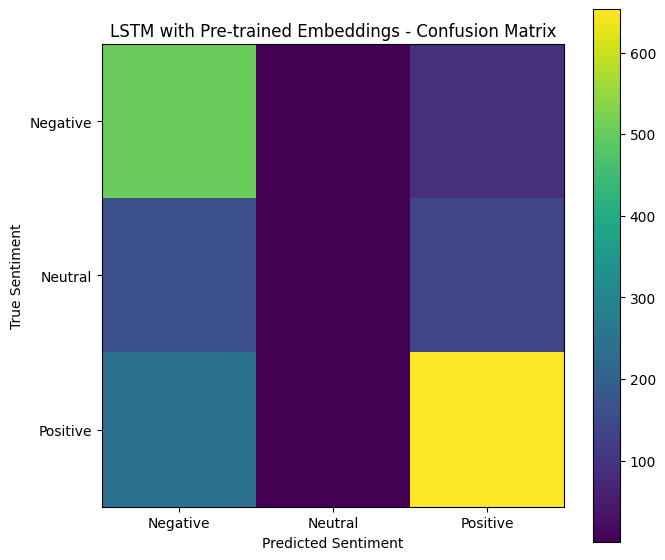

In [24]:
plot_history(history_pretrained_lstm, "LSTM with Pre-trained Embeddings")
pretrained_results, pretrained_pred, pretrained_prob = evaluate_text_model(
    pretrained_lstm_model,
    X_test_pad,
    y_test,
    "LSTM with Pre-trained Embeddings"
)


# Model 4: Bidirectional LSTM with Pre-trained Embeddings

This additional model is included to improve accuracy and F1-score.

A Bidirectional LSTM reads the text sequence in both forward and backward directions, which can help the model understand review context more effectively. The pre-trained embedding layer is also made trainable so the word vectors can adjust to the book review dataset during training.


In [25]:
# Model 4: Bidirectional LSTM with Pre-trained Embeddings
# This model is added to improve accuracy and F1-score.

def build_bilstm_pretrained_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_SEQUENCE_LENGTH,
            trainable=True
        ),

        SpatialDropout1D(0.3),

        Bidirectional(LSTM(128, return_sequences=False)),

        Dropout(0.5),

        Dense(128, activation="relu"),
        Dropout(0.4),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


bilstm_pretrained_model = build_bilstm_pretrained_model()
bilstm_pretrained_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
EPOCHS_BILSTM = 12

print("Training Bidirectional LSTM with pre-trained embeddings...")
start_time = time.time()

history_bilstm_pretrained = bilstm_pretrained_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_BILSTM,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

bilstm_pretrained_time = time.time() - start_time
print(f"Bidirectional LSTM training time: {bilstm_pretrained_time:.2f} seconds")


Training Bidirectional LSTM with pre-trained embeddings...
Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 137s 918ms/step - accuracy: 0.4668 - loss: 1.0372 - val_accuracy: 0.7000 - val_loss: 0.7674 - learning_rate: 5.0000e-04
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 117s 739ms/step - accuracy: 0.6321 - loss: 0.8964 - val_accuracy: 0.7100 - val_loss: 0.7156 - learning_rate: 5.0000e-04
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 101s 769ms/step - accuracy: 0.6654 - loss: 0.8330 - val_accuracy: 0.6961 - val_loss: 0.7204 - learning_rate: 5.0000e-04
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 97s 729ms/step - accuracy: 0.6951 - loss: 0.7773 - val_accuracy: 0.7106 - val_loss: 0.6766 - learning_rate: 5.0000e-04
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 95s 717ms/step - accuracy: 0.7162 - loss: 0.7375 - val_accuracy: 0.7050 - val_loss: 0.6852 - learning_rate: 5.0000e-04
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 142s 718ms/step - accuracy: 0.7210 - loss: 0.7019 - val_accuracy: 0.7156 - val_loss: 0.6471 - learning_

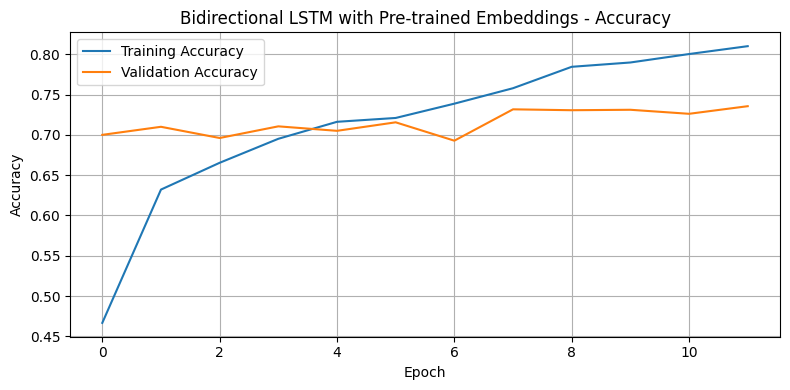

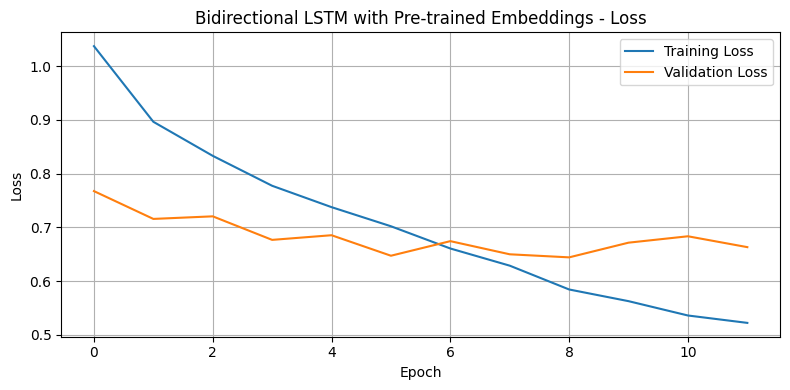


Bidirectional LSTM with Pre-trained Embeddings Test Evaluation
Accuracy : 0.7400
Precision: 0.7771
Recall   : 0.7400
F1-score : 0.7534

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82       600
     Neutral       0.37      0.53      0.44       300
    Positive       0.89      0.75      0.81       900

    accuracy                           0.74      1800
   macro avg       0.69      0.70      0.69      1800
weighted avg       0.78      0.74      0.75      1800



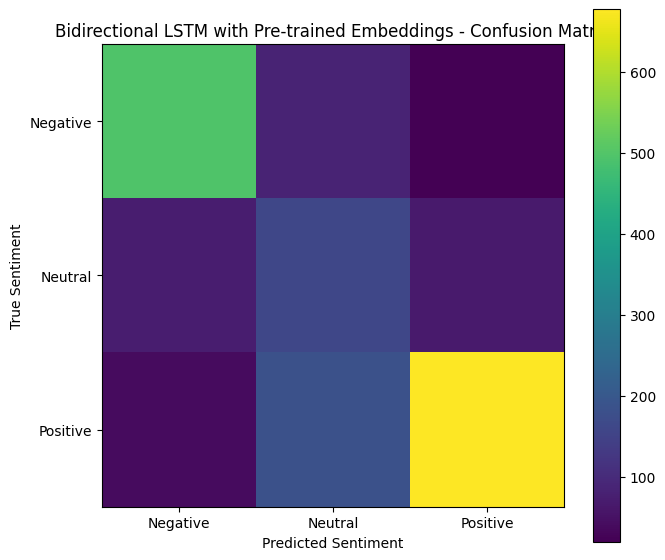

In [27]:
plot_history(history_bilstm_pretrained, "Bidirectional LSTM with Pre-trained Embeddings")

bilstm_pretrained_results, bilstm_pretrained_pred, bilstm_pretrained_prob = evaluate_text_model(
    bilstm_pretrained_model,
    X_test_pad,
    y_test,
    "Bidirectional LSTM with Pre-trained Embeddings"
)


## 11. Final Model Comparison


Simple RNN Test Evaluation
Accuracy : 0.3456
Precision: 0.3788
Recall   : 0.3456
F1-score : 0.2511

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.88      0.49       600
     Neutral       0.14      0.04      0.06       300
    Positive       0.48      0.09      0.15       900

    accuracy                           0.35      1800
   macro avg       0.32      0.34      0.24      1800
weighted avg       0.38      0.35      0.25      1800



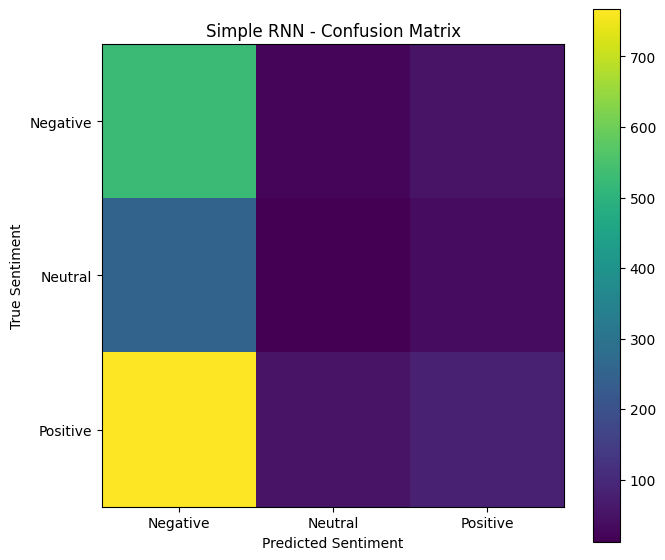


LSTM Test Evaluation
Accuracy : 0.3511
Precision: 0.4354
Recall   : 0.3511
F1-score : 0.2430

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.92      0.49       600
     Neutral       0.24      0.04      0.06       300
    Positive       0.57      0.08      0.14       900

    accuracy                           0.35      1800
   macro avg       0.38      0.34      0.23      1800
weighted avg       0.44      0.35      0.24      1800



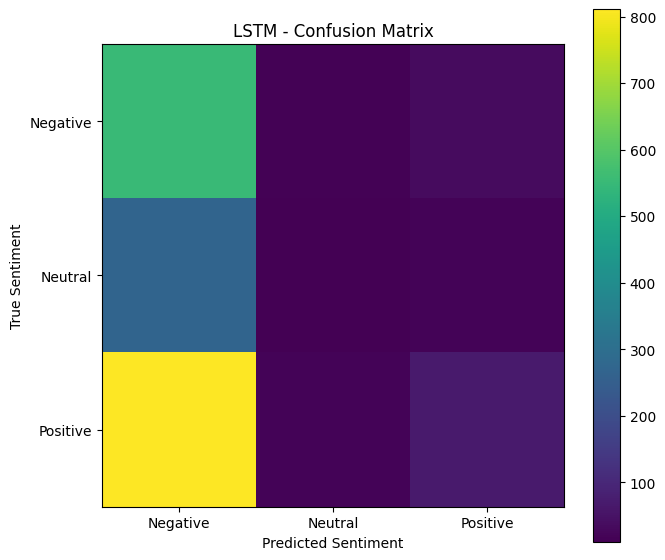

,model,accuracy,precision,recall,f1_score,training_time_seconds
3,Bidirectional LSTM with Pre-trained Embeddings,0.740000,0.777052,0.740000,0.753416,1272.094304
2,LSTM with Pre-trained Embeddings,0.645556,0.610828,0.645556,0.592108,323.910712
0,Simple RNN,0.345556,0.378828,0.345556,0.251078,122.539495
1,LSTM,0.351111,0.435387,0.351111,0.242987,278.060652


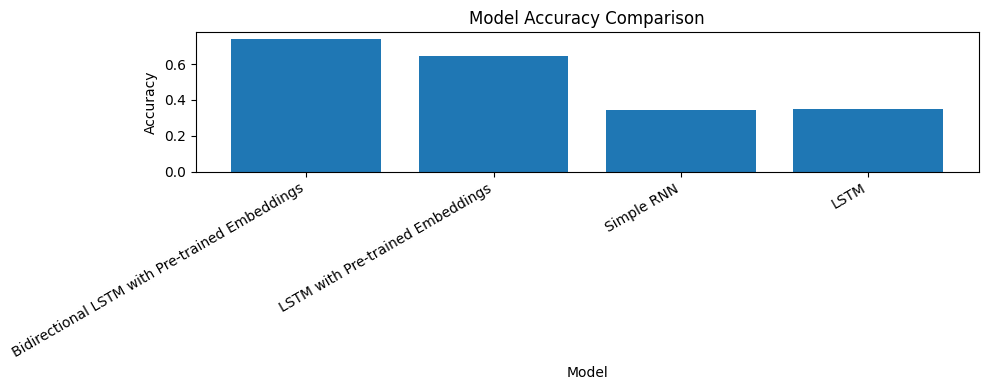

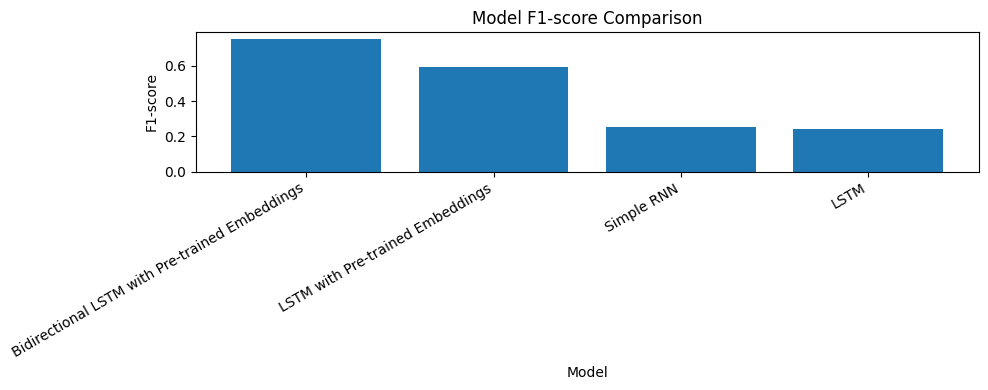

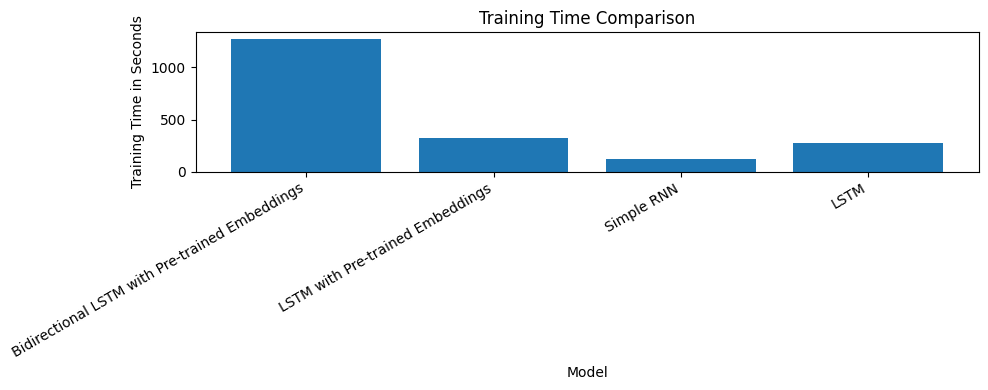

In [28]:
rnn_results, rnn_pred, rnn_prob = evaluate_text_model(rnn_model, X_test_pad, y_test, "Simple RNN")
lstm_results, lstm_pred, lstm_prob = evaluate_text_model(lstm_model, X_test_pad, y_test, "LSTM")

results = [rnn_results, lstm_results, pretrained_results, bilstm_pretrained_results]
results_df = pd.DataFrame(results)

training_times = {
    "Simple RNN": rnn_time,
    "LSTM": lstm_time,
    "LSTM with Pre-trained Embeddings": pretrained_lstm_time,
    "Bidirectional LSTM with Pre-trained Embeddings": bilstm_pretrained_time
}

results_df["training_time_seconds"] = results_df["model"].map(training_times)
results_df = results_df.sort_values(by="f1_score", ascending=False)

display(results_df)

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["f1_score"])
plt.title("Model F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["training_time_seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. Error Analysis

This section displays a few misclassified reviews from the best-performing model.  
It helps explain why the model may make mistakes, such as:

- reviews containing mixed opinions  
- sarcastic language  
- very short reviews  
- neutral reviews being closer to positive or negative sentiment  
- rating ambiguity between nearby classes  


In [29]:
# Select best model based on F1-score
best_model_name = results_df.iloc[0]["model"]

if best_model_name == "Simple RNN":
    best_pred = rnn_pred
    best_prob = rnn_prob
elif best_model_name == "LSTM":
    best_pred = lstm_pred
    best_prob = lstm_prob
elif best_model_name == "LSTM with Pre-trained Embeddings":
    best_pred = pretrained_pred
    best_prob = pretrained_prob
else:
    best_pred = bilstm_pretrained_pred
    best_prob = bilstm_pretrained_prob

print("Best model selected for error analysis:", best_model_name)

test_df = df_model.loc[test_idx].copy()
test_df["true_sentiment"] = [label_mapping[int(label)] for label in y_test]
test_df["predicted_sentiment"] = [label_mapping[int(label)] for label in best_pred]
test_df["confidence"] = np.max(best_prob, axis=1)

misclassified = test_df[test_df["true_sentiment"] != test_df["predicted_sentiment"]].copy()
misclassified = misclassified.sort_values(by="confidence", ascending=False)

print("Number of misclassified test examples:", len(misclassified))

display(misclassified[["summary", "reviewText", "true_sentiment", "predicted_sentiment", "confidence"]].head(5))

for i, row in misclassified.head(3).iterrows():
    print("\n" + "=" * 80)
    print("Summary:", row["summary"])
    print("True sentiment:", row["true_sentiment"])
    print("Predicted sentiment:", row["predicted_sentiment"])
    print("Confidence:", round(row["confidence"], 3))
    print("Review excerpt:", str(row["reviewText"])[:700])


Best model selected for error analysis: Bidirectional LSTM with Pre-trained Embeddings
Number of misclassified test examples: 468


,summary,reviewText,true_sentiment,predicted_sentiment,confidence
700,SEAL and a Psychic,Will has been in love with his best friend sin...,Neutral,Positive,0.990314
10024,An Erotic Dream for sure...,Dream Machine surprised me in more ways than o...,Neutral,Positive,0.988117
8404,Chasing Sunset,Andrew Buchanan was a man that had everything....,Neutral,Positive,0.985737
455,"Love, the Bible, Mysticism, Zombies, Crystals ...","Meet Cody McGrath, a cowboy with bright blue e...",Neutral,Positive,0.982229
8708,Implausible even for fiction,"When I read a mystery, I look for some semblan...",Neutral,Negative,0.980908



Summary: SEAL and a Psychic
True sentiment: Neutral
Predicted sentiment: Positive
Confidence: 0.99
Review excerpt: Will has been in love with his best friend since they were 15 years old.  Now 30, he's serving in the Navy as a SEAL.  He's tired of being "just friends."  He shows up at Mackenzie's house in the middle of the night and gives her an ultimatum.  "Be my lover or nothing at all."  Mackenzie has psychic visions and has the ability to read others' minds.  This has created rifts in her relationships with other men.  She has a vision of a helicopter crashing, with Will in it, so she kicks him to the friend zone to protect her own heart.Another reviewer commented on the childishness of the character's actions.  I agree.  A lot of the reasoning and decision making is not based on mature love.  It's b

Summary: An Erotic Dream for sure...
True sentiment: Neutral
Predicted sentiment: Positive
Confidence: 0.988
Review excerpt: Dream Machine surprised me in more ways than one. First t

## 13. Real-time Sentiment Prediction Function

In [30]:
def preprocess_single_text(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    return padded

# Use best model for real-time prediction
if best_model_name == "Simple RNN":
    final_model = rnn_model
elif best_model_name == "LSTM":
    final_model = lstm_model
elif best_model_name == "LSTM with Pre-trained Embeddings":
    final_model = pretrained_lstm_model
else:
    final_model = bilstm_pretrained_model

def predict_book_sentiment(review_text):
    padded = preprocess_single_text(review_text)
    prob = final_model.predict(padded, verbose=0)[0]
    predicted_label = int(np.argmax(prob))
    predicted_sentiment = label_mapping[predicted_label]
    confidence = float(np.max(prob))

    return predicted_sentiment, confidence, prob

sample_review = "This book was exciting, well written, and very enjoyable. I would recommend it to other readers."
pred_sentiment, conf, prob = predict_book_sentiment(sample_review)

print("Sample review:", sample_review)
print("Predicted sentiment:", pred_sentiment)
print("Confidence:", round(conf, 3))
print("Class probabilities:", prob)


Sample review: This book was exciting, well written, and very enjoyable. I would recommend it to other readers.
Predicted sentiment: Positive
Confidence: 0.938
Class probabilities: [0.00355738 0.05851061 0.937932  ]


## 14. Optional GUI using Gradio

This is included for the coursework GUI requirement.

By default, `RUN_GRADIO_DEMO = False` so that **Run all** does not get stuck launching an app.  
To use the GUI, change it to `True` and run this cell manually.


In [31]:
RUN_GRADIO_DEMO = False

if RUN_GRADIO_DEMO:
    try:
        import gradio as gr
    except Exception:
        !pip -q install gradio
        import gradio as gr

    def gradio_predict(review_text):
        sentiment, confidence, probabilities = predict_book_sentiment(review_text)
        return f"Predicted Sentiment: {sentiment} | Confidence: {confidence:.2f}"

    demo = gr.Interface(
        fn=gradio_predict,
        inputs=gr.Textbox(lines=5, placeholder="Enter a book review..."),
        outputs="text",
        title="Book Review Sentiment Predictor",
        description="Enter a book review and the model will predict Negative, Neutral, or Positive sentiment."
    )

    demo.launch(share=False)
else:
    print("Gradio demo is disabled. Set RUN_GRADIO_DEMO = True to launch the GUI manually.")


Gradio demo is disabled. Set RUN_GRADIO_DEMO = True to launch the GUI manually.


## 15. Save Best Model and Tokenizer

This cell saves the best model and tokenizer so predictions can be made later without retraining.


In [32]:
import pickle

SAVE_DIR = "/content/drive/MyDrive/book_review_sentiment_nlp_model"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_book_review_sentiment_model.keras")
tokenizer_path = os.path.join(SAVE_DIR, "book_review_tokenizer.pkl")

final_model.save(best_model_path)

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

metadata = {
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "best_model_name": best_model_name,
    "label_mapping": "0=Negative, 1=Neutral, 2=Positive",
    "rating_conversion": "ratings 1-2=Negative, rating 3=Neutral, ratings 4-5=Positive"
}

metadata_path = os.path.join(SAVE_DIR, "metadata.txt")
with open(metadata_path, "w") as f:
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")

print("Best model saved to:", best_model_path)
print("Tokenizer saved to:", tokenizer_path)
print("Metadata saved to:", metadata_path)


Best model saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/best_book_review_sentiment_model.keras
Tokenizer saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/book_review_tokenizer.pkl
Metadata saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/metadata.txt


## 16. Report Notes

Use these points in your final report:

- The original target rating was converted into three sentiment classes: Negative, Neutral, and Positive.
- Ratings 1–2 were mapped to Negative, rating 3 to Neutral, and ratings 4–5 to Positive.
- This conversion aligns the dataset with the coursework requirement for sentiment analysis/text classification.
- The `summary` and `reviewText` columns were combined to provide richer textual input.
- Text preprocessing included lowercasing, contraction handling, URL removal, special character removal, stopword removal, and lemmatization.
- Negation words such as `not`, `no`, and `nor` were preserved because they are important for sentiment meaning.
- The dataset was split into training, validation, and test sets using stratified sampling.
- Tokenization was performed using Keras Tokenizer.
- Percentile-based padding was used to avoid excessively long sequences.
- Four models were implemented: Simple RNN, LSTM, LSTM with pre-trained embeddings, and Bidirectional LSTM with pre-trained embeddings.
- Models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report.
- Error analysis was performed by examining misclassified reviews.
- A real-time prediction function and optional Gradio interface were included.
